In [40]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

def load(filename):
    return kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "nikdavis/steam-store-games",
        filename,
    )

steam                = load("steam.csv")
steam_description    = load("steam_description_data.csv")
steam_media          = load("steam_media_data.csv")
steam_requirements   = load("steam_requirements_data.csv")
steam_support        = load("steam_support_info.csv")
steamspy_tags        = load("steamspy_tag_data.csv")

print("steam:              ", steam.shape)
print("steam_description:  ", steam_description.shape)
print("steam_media:        ", steam_media.shape)
print("steam_requirements: ", steam_requirements.shape)
print("steam_support:      ", steam_support.shape)
print("steamspy_tags:      ", steamspy_tags.shape)

steam:               (27075, 18)
steam_description:   (27334, 4)
steam_media:         (27332, 5)
steam_requirements:  (27319, 6)
steam_support:       (27136, 4)
steamspy_tags:       (29022, 372)


In [41]:
print(steam.dtypes)
print("-" * 40)
print(steam_description.dtypes)
print("-" * 40)
print(steam_media.dtypes)
print("-" * 40)
print(steam_requirements.dtypes)
print("-" * 40)
print(steam_support.dtypes)
print("-" * 40)
print(steamspy_tags.dtypes)

appid                 int64
name                    str
release_date            str
english               int64
developer               str
publisher               str
platforms               str
required_age          int64
categories              str
genres                  str
steamspy_tags           str
achievements          int64
positive_ratings      int64
negative_ratings      int64
average_playtime      int64
median_playtime       int64
owners                  str
price               float64
dtype: object
----------------------------------------
steam_appid             int64
detailed_description      str
about_the_game            str
short_description         str
dtype: object
----------------------------------------
steam_appid     int64
header_image      str
screenshots       str
background        str
movies            str
dtype: object
----------------------------------------
steam_appid           int64
pc_requirements         str
mac_requirements        str
linux_requirement

## Propose two different definitions of “success” and compare whether they identify the multiple games. 

In [42]:
import numpy as np
from scipy.stats import norm

# --- Definition 1: Reception success (Wilson score lower bound) ---
# Encodes both positive ratio and rating count into one score.
# A high-ratio game with few reviews scores lower than a slightly-lower-ratio game with thousands.
z = norm.ppf(0.975)
n = steam["positive_ratings"] + steam["negative_ratings"]
p = steam["positive_ratings"] / n.where(n > 0)
steam["wilson_score"] = (
    p + z**2 / (2 * n) - z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
) / (1 + z**2 / n)

# --- Definition 2: Engagement success (playtime × reach, log-geometric mean) ---
# Captures both depth (how long players play) and breadth (how many own it).
steam["owners_mid"] = (
    steam["owners"].str.replace(",", "", regex=False)
    .str.extract(r"(\d+)-(\d+)").astype(float).mean(axis=1)
)
steam["engagement_score"] = (
    np.log1p(steam["average_playtime"]) + np.log1p(steam["owners_mid"])
) / 2

# --- Top 10% threshold for each definition ---
ws_thresh  = steam["wilson_score"].quantile(0.90)
eng_thresh = steam["engagement_score"].quantile(0.90)

success_reception  = steam[steam["wilson_score"]  >= ws_thresh]
success_engagement = steam[steam["engagement_score"] >= eng_thresh]

print("Top 10% by reception (Wilson score):")
print(success_reception[["name", "positive_ratings", "negative_ratings", "wilson_score"]]
      .sort_values("wilson_score", ascending=False).head(5).to_string(index=False))

print("\nTop 10% by engagement (playtime × owners):")
print(success_engagement[["name", "average_playtime", "owners", "engagement_score"]]
      .sort_values("engagement_score", ascending=False).head(5).to_string(index=False))

Top 10% by reception (Wilson score):
                                name  positive_ratings  negative_ratings  wilson_score
                 Sabbat of the Witch               521                 2      0.986165
                            Portal 2            138220              1891      0.985886
                            Factorio             47918               723      0.984022
東方天空璋 ～ Hidden Star in Four Seasons.              4114                53      0.983402
                      planetarian HD               927                10      0.980467

Top 10% by engagement (playtime × owners):
                            name  average_playtime              owners  engagement_score
                          Dota 2             23944 100000000-200000000         14.454830
   PLAYERUNKNOWN'S BATTLEGROUNDS             22938  50000000-100000000         14.086796
Counter-Strike: Global Offensive             22494  50000000-100000000         14.077024
                 Team Fortress 2         

/var/folders/4s/_zql0bq16hd92_s5p_mq67480000gn/T/ipykernel_17420/4244934397.py:39: UserWarning: Glyph 26481 (\N{CJK UNIFIED IDEOGRAPH-6771}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4s/_zql0bq16hd92_s5p_mq67480000gn/T/ipykernel_17420/4244934397.py:39: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4s/_zql0bq16hd92_s5p_mq67480000gn/T/ipykernel_17420/4244934397.py:39: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4s/_zql0bq16hd92_s5p_mq67480000gn/T/ipykernel_17420/4244934397.py:39: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4s/_zql0bq16hd92_s5p_mq67480000gn/T/ipykernel_17420/4244934397.py:39: UserWarning: Glyph 29835 (\N{CJK UNIFIED IDEOGRAPH-748B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4s/_zql

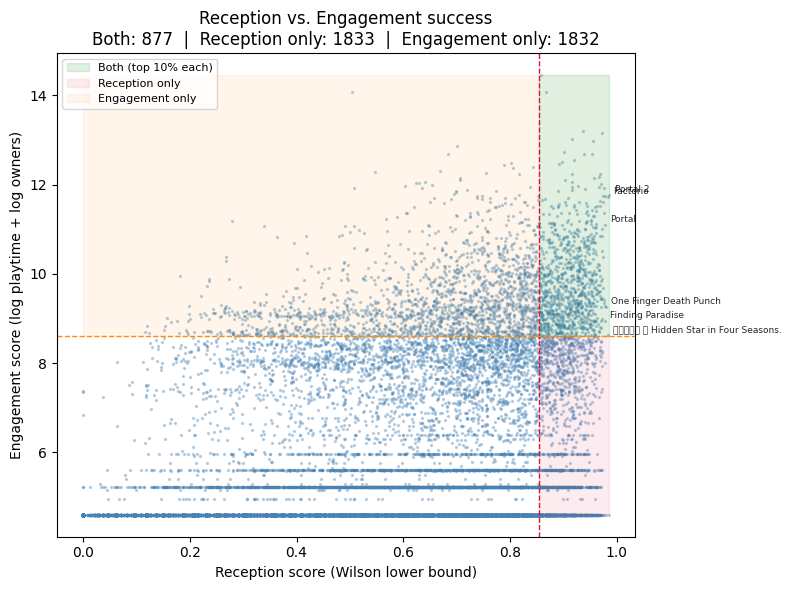

In [43]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(steam["wilson_score"], steam["engagement_score"],
           s=2, alpha=0.3, color="steelblue")

ws_thresh = steam["wilson_score"].quantile(0.90)
eng_thresh = steam["engagement_score"].quantile(0.90)

ax.axvline(ws_thresh, color="crimson", linewidth=1, linestyle="--")
ax.axhline(eng_thresh, color="darkorange", linewidth=1, linestyle="--")

ax.fill_betweenx([eng_thresh, steam["engagement_score"].max()],
                 ws_thresh, steam["wilson_score"].max(),
                 alpha=0.12, color="green", label="Both (top 10% each)")
ax.fill_betweenx([steam["engagement_score"].min(), eng_thresh],
                 ws_thresh, steam["wilson_score"].max(),
                 alpha=0.08, color="crimson", label="Reception only")
ax.fill_betweenx([eng_thresh, steam["engagement_score"].max()],
                 steam["wilson_score"].min(), ws_thresh,
                 alpha=0.08, color="darkorange", label="Engagement only")

top = steam[(steam["wilson_score"] >= ws_thresh) & (steam["engagement_score"] >= eng_thresh)]
for _, row in top.nlargest(6, "wilson_score").iterrows():
    ax.annotate(row["name"], (row["wilson_score"], row["engagement_score"]),
                fontsize=6.5, alpha=0.85, xytext=(4, 2), textcoords="offset points")

n_both   = ((steam["wilson_score"] >= ws_thresh) & (steam["engagement_score"] >= eng_thresh)).sum()
n_rec    = ((steam["wilson_score"] >= ws_thresh) & (steam["engagement_score"] < eng_thresh)).sum()
n_eng    = ((steam["wilson_score"] < ws_thresh)  & (steam["engagement_score"] >= eng_thresh)).sum()

ax.set_xlabel("Reception score (Wilson lower bound)")
ax.set_ylabel("Engagement score (log playtime + log owners)")
ax.set_title(f"Reception vs. Engagement success\n"
             f"Both: {n_both}  |  Reception only: {n_rec}  |  Engagement only: {n_eng}")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [44]:
from scipy.stats import pearsonr, spearmanr

# Remove the low-engagement cluster (games with no recorded playtime)
steam_active = steam[steam["average_playtime"] > 0].dropna(subset=["wilson_score", "engagement_score"])

pearson_r,  pearson_p  = pearsonr(steam_active["wilson_score"], steam_active["engagement_score"])
spearman_r, spearman_p = spearmanr(steam_active["wilson_score"], steam_active["engagement_score"])

print(f"Games with recorded playtime: {len(steam_active):,} (removed {len(steam) - len(steam_active):,} zero-playtime entries)")
print(f"Pearson  r = {pearson_r:.3f}  (p = {pearson_p:.2e})")
print(f"Spearman r = {spearman_r:.3f}  (p = {spearman_p:.2e})")

Games with recorded playtime: 6,170 (removed 20,905 zero-playtime entries)
Pearson  r = 0.292  (p = 3.07e-121)
Spearman r = 0.281  (p = 1.11e-112)


The two definitions identify largely different games. Among games with recorded playtime, reception and engagement scores are only weakly correlated, confirming they capture distinct dimensions of success. Reception rewards beloved but niche titles; engagement rewards mass-market games that are widely owned and heavily played.

## How does price relate to player reception?


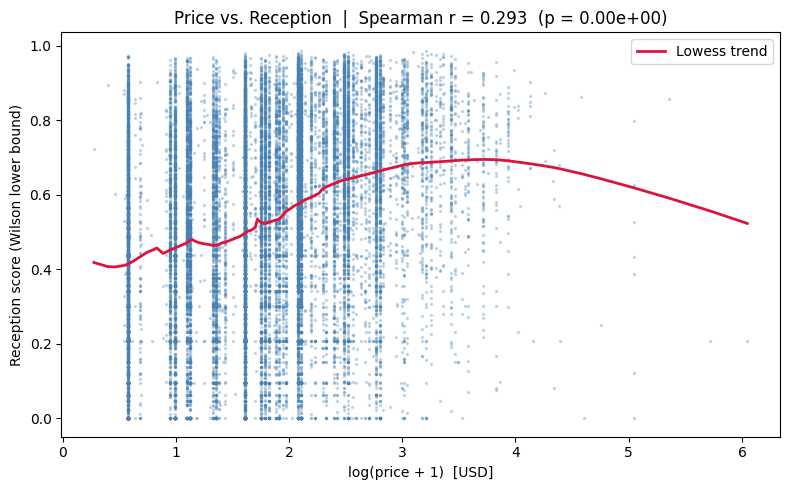

Spearman r = 0.293, p = 0.00e+00, n = 24,515


In [47]:
steam_paid = steam[(steam["price"] > 0)].dropna(subset=["wilson_score", "price"])

x2 = np.log1p(steam_paid["price"])
y2 = steam_paid["wilson_score"]

spearman_r2, spearman_p2 = spearmanr(x2, y2)
smoothed2 = sm.nonparametric.lowess(y2, x2, frac=0.2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x2, y2, s=2, alpha=0.25, color="steelblue")
ax.plot(smoothed2[:, 0], smoothed2[:, 1], color="crimson", linewidth=2, label="Lowess trend")
ax.set_xlabel("log(price + 1)  [USD]")
ax.set_ylabel("Reception score (Wilson lower bound)")
ax.set_title(f"Price vs. Reception  |  Spearman r = {spearman_r2:.3f}  (p = {spearman_p2:.2e})")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Spearman r = {spearman_r2:.3f}, p = {spearman_p2:.2e}, n = {len(steam_paid):,}")

Higher price is moderately associated with better reception (Spearman r = 0.29), a stronger relationship than playtime. This likely reflects that higher-priced games have greater production investment, and players who pay more self-select into titles they expect to enjoy.

## How does playtime relate to player reception?  


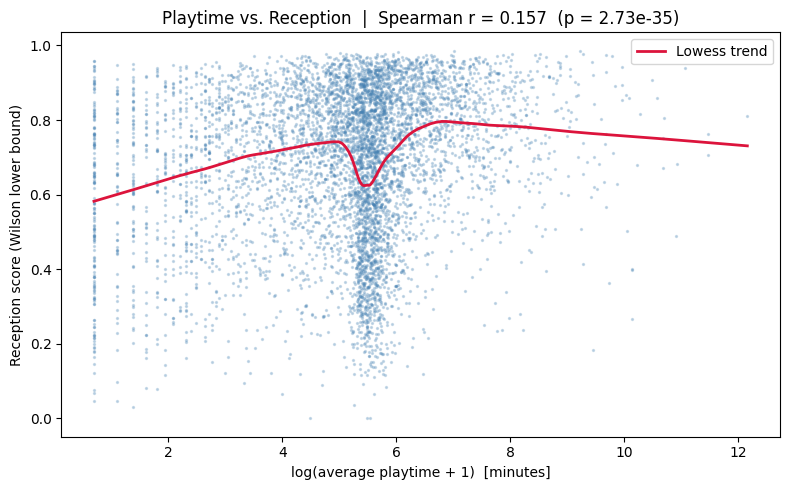

Spearman r = 0.157, p = 2.73e-35, n = 6,170


In [48]:
import statsmodels.api as sm
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import numpy as np

x = np.log1p(steam_active["average_playtime"])
y = steam_active["wilson_score"]

spearman_r, spearman_p = spearmanr(x, y)
smoothed = sm.nonparametric.lowess(y, x, frac=0.2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, s=2, alpha=0.25, color="steelblue")
ax.plot(smoothed[:, 0], smoothed[:, 1], color="crimson", linewidth=2, label="Lowess trend")
ax.set_xlabel("log(average playtime + 1)  [minutes]")
ax.set_ylabel("Reception score (Wilson lower bound)")
ax.set_title(f"Playtime vs. Reception  |  Spearman r = {spearman_r:.3f}  (p = {spearman_p:.2e})")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.2e}, n = {len(steam_active):,}")

Higher playtime is weakly associated with better reception (Spearman r = 0.16), meaning players do tend to spend more time in games they rate well. The relationship is weak because competitive and multiplayer games accumulate massive playtime regardless of review sentiment, pulling the correlation down.